In [149]:
import pandas as pd
import numpy as np
import helper
import importlib
importlib.reload(project1); importlib.reload(helper)

<module 'helper' from '/Users/lukemcguinness/Documents/Academics/EECS/eecs445/P1/helper.py'>

In [186]:
def summarize_features(X: np.ndarray, feature_names: list[str]) -> pd.DataFrame:
    # use nan-safe versions just in case
    means = np.nanmean(X, axis=0)
    q1    = np.nanpercentile(X, 25, axis=0)
    q3    = np.nanpercentile(X, 75, axis=0)
    iqr   = q3 - q1

    df = pd.DataFrame({
        "Feature": feature_names,
        "Mean Value": np.round(means, 4),
        "Interquartile Range": np.round(iqr, 4),
    })
    return df.sort_values("Feature").reset_index(drop=True)


import importlib, project1, helper
importlib.reload(project1)      # reload the dependency first
importlib.reload(helper)        # then the caller

X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)
summary_df = summarize_features(X_train, feature_names)
print(summary_df.to_string(index=False))

Loading training_subset data: 100%|██████████| 2000/2000 [00:04<00:00, 473.13it/s]


Loaded n = 2000 feature vectors
        Feature  Mean Value  Interquartile Range
            Age      0.6471               0.3378
         Gender      0.5790               1.0000
         Height      0.3722               0.0008
        ICUType      0.5933               0.6667
         Weight      0.2950               0.1136
        max_ALP      0.0717               0.0165
        max_ALT      0.0156               0.0137
        max_AST      0.0157               0.0138
    max_Albumin      0.5053               0.0000
        max_BUN      0.1319               0.0979
  max_Bilirubin      0.0430               0.0252
max_Cholesterol      0.3261               0.0000
 max_Creatinine      0.0649               0.0334
    max_DiasABP      0.3330               0.0394
       max_FiO2      0.7504               0.4167
        max_GCS      0.8772               0.2500
    max_Glucose      0.1389               0.0684
       max_HCO3      0.3503               0.1389
        max_HCT      0.3335          

In [158]:
from sklearn.linear_model import LogisticRegression

X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)

def run_section2c_report(
    X: np.ndarray,
    y: np.ndarray,
    k: int = 5,
) -> None:
    """
    Sweep C and penalty for each metric using select_param_logreg,
    then report best (C, penalty) and the mean (min, max) CV performance.

    Prints a table with 4 decimal places, matching the spec.
    """
    # Metrics to evaluate
    metrics = [
        "accuracy",
        "precision",
        "f1_score",
        "auroc",
        "average_precision",
        "sensitivity",
        "specificity",
    ]

    # C values: powers of 10 from 1e-3 to 1e3
    C_range = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3]
    penalties = ["l1", "l2"]

    rows = []
    for m in metrics:
        # choose best hyperparams via your function
        best_C, best_penalty = project1.select_param_logreg(
            X=X, y=y, C_range=C_range, penalties=penalties, metric=m, k=k
        )

        # re-evaluate that setting to get mean/min/max CV performance
        clf = LogisticRegression(
            penalty=best_penalty,
            C=best_C,
            solver="liblinear",
            fit_intercept=False,
            random_state=42, # chose seed from .yaml
        )

        # no bootstrapping by default
        mean_cv, min_cv, max_cv = project1.cv_performance(clf, X, y, metric=m, k=k)

        rows.append(
            {
                "Performance Measure": m,
                "C": best_C,
                "Penalty": best_penalty,
                "Mean (Min, Max) CV Performance": f"{mean_cv:.4f} ({min_cv:.4f}, {max_cv:.4f})",
            }
        )

    df = pd.DataFrame(rows, columns=[
        "Performance Measure", "C", "Penalty", "Mean (Min, Max) CV Performance"
    ])
    print(df.to_string(index=False))


X_train, y_train, X_test, y_test, feature_names = helper.get_project_data()
run_section2c_report(X_train, y_train, k=5)

Loading training_subset data: 100%|██████████| 2000/2000 [00:00<00:00, 3380.27it/s]


Loaded n = 2000 feature vectors
Performance Measure     C Penalty Mean (Min, Max) CV Performance
           accuracy 0.100      l1        0.8606 (0.8594, 0.8625)
          precision 1.000      l2        0.6024 (0.1667, 1.0000)
           f1_score 0.001      l1        0.2456 (0.2418, 0.2466)
              auroc 1.000      l2        0.7804 (0.7539, 0.8192)
  average_precision 1.000      l2        0.3923 (0.2893, 0.4965)
        sensitivity 0.001      l1        1.0000 (1.0000, 1.0000)
        specificity 0.001      l2        1.0000 (1.0000, 1.0000)


In [160]:
X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=-1)

def evaluate_with_bootstrap(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    best_C: float,
    best_penalty: str,
    metrics: list[str],
    B: int = 1000,
) -> pd.DataFrame:
    """
    Train logistic regression with best hyperparameters, evaluate on test set
    using bootstrap resampling, and report median + 95% CI for each metric.
    """

    # Train model on full training set
    clf = LogisticRegression(
        penalty=best_penalty,
        C=best_C,
        solver="liblinear",
        fit_intercept=False,
        random_state=42, # global seed
    )
    clf.fit(X_train, y_train)

    results = []

    # Loop over metrics
    for metric in metrics:
        # Use performance(...) with bootstrap=True
        median, lo, hi = project1.performance(clf, X_test, y_test, metric=metric, bootstrap=True)
        results.append({
            "Performance Measure": metric,
            "Median": round(median, 4),
            "95% Confidence Interval": f"({lo:.4f}, {hi:.4f})"
        })

    return pd.DataFrame(results)


best_C = 1.0
best_penalty = "l2"

metrics = ["accuracy", "precision", "f1_score", "auroc", "average_precision", "sensitivity", "specificity"]
table3_df = evaluate_with_bootstrap(X_train, y_train, X_test, y_test, best_C, best_penalty, metrics)
print(table3_df.to_string(index=False))

Loading training_subset data: 100%|██████████| 2000/2000 [00:00<00:00, 3794.25it/s]


Loaded n = 2000 feature vectors
Performance Measure  Median 95% Confidence Interval
           accuracy  0.8575        (0.8200, 0.8875)
          precision  0.4167        (0.1429, 0.7273)
           f1_score  0.1449        (0.0351, 0.2623)
              auroc  0.7832        (0.7272, 0.8348)
  average_precision  0.3586        (0.2472, 0.4760)
        sensitivity  0.0877        (0.0200, 0.1703)
        specificity  0.9798        (0.9645, 0.9942)


In [173]:
X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)
C_range = [1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
penalties = ["l1", "l2"]

project1.plot_weight(X_train, y_train, C_range, penalties)

Loading training_subset data: 100%|██████████| 2000/2000 [00:03<00:00, 528.90it/s]


Loaded n = 2000 feature vectors
Plotting the number of nonzero entries of the parameter vector as a function of C


In [184]:
X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)

clf = LogisticRegression(penalty="l1", C=1.0, solver="liblinear", fit_intercept=False, random_state=42)
clf.fit(X_train, y_train)

w = clf.coef_.ravel()

pos_idx = np.argsort(w)[-4:] # top 4 ASC
neg_idx = np.argsort(w)[:4]  # 4 ASC

pos_rows = [(round(float(w[i]), 4), feature_names[i]) for i in pos_idx[::-1]] # reverse our pos_idx to be DESC
neg_rows = [(round(float(w[i]), 4), feature_names[i]) for i in neg_idx]

pos_df = pd.DataFrame(pos_rows, columns=["Positive Coefficient", "Feature Name"])
neg_df = pd.DataFrame(neg_rows, columns=["Negative Coefficient", "Feature Name"])

print(pos_df.to_string(index=False))
print(neg_df.to_string(index=False))

Loading training_subset data: 100%|██████████| 2000/2000 [00:04<00:00, 496.36it/s]

Loaded n = 2000 feature vectors
 Positive Coefficient  Feature Name
               4.1053 max_Bilirubin
               2.5931       max_BUN
               1.6193        max_HR
               1.5566           Age
 Negative Coefficient Feature Name
              -2.7041      max_GCS
              -2.0179    max_Urine
              -0.9237     max_SaO2
              -0.8589     max_HCO3


In [188]:
X_train, y_train, X_test, y_test, feature_names = helper.get_project_data(n_jobs=1)

class_weights = {-1: 1, 1: 50}

clf = project1.get_classifier(
    loss="logistic",
    penalty="l2",
    C=1.0,
    class_weight=class_weights
)

clf.fit(X_train, y_train)

metrics = ["accuracy", "precision", "f1_score", "auroc", 
           "average_precision", "sensitivity", "specificity"]

results = []

for metric in metrics:
    median, lo, hi = project1.performance(clf, X_test, y_test, metric=metric, bootstrap=True)
    results.append({
        "Performance Measure": metric,
        "Median": round(median, 4),
        "95% Confidence Interval": f"({lo:.4f}, {hi:.4f})"
    })

table5_df = pd.DataFrame(results)
print(table5_df.to_string(index=False))

Loading training_subset data: 100%|██████████| 2000/2000 [00:03<00:00, 505.38it/s]


Loaded n = 2000 feature vectors
Performance Measure  Median 95% Confidence Interval
           accuracy  0.2400        (0.2024, 0.2850)
          precision  0.1542        (0.1181, 0.1931)
           f1_score  0.2671        (0.2112, 0.3237)
              auroc  0.7406        (0.6781, 0.7977)
  average_precision  0.3493        (0.2367, 0.4605)
        sensitivity  1.0000        (1.0000, 1.0000)
        specificity  0.1192        (0.0850, 0.1557)


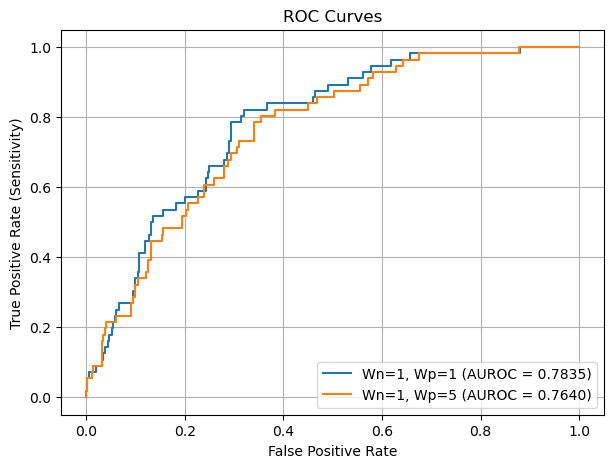

In [190]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Train model with Wn=1, Wp=1
clf_balanced = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    fit_intercept=False,
    random_state=42,
    class_weight={-1: 1, 1: 1}
)
clf_balanced.fit(X_train, y_train)
scores_balanced = clf_balanced.decision_function(X_test)
fpr_bal, tpr_bal, _ = roc_curve(y_test, scores_balanced, pos_label=1)
roc_auc_bal = auc(fpr_bal, tpr_bal)



# Train model with Wn=1, Wp=5
clf_weighted = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    fit_intercept=False,
    random_state=42,
    class_weight={-1: 1, 1: 5}
)
clf_weighted.fit(X_train, y_train)
scores_weighted = clf_weighted.decision_function(X_test)
fpr_w, tpr_w, _ = roc_curve(y_test, scores_weighted, pos_label=1)
roc_auc_w = auc(fpr_w, tpr_w)

# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_bal, tpr_bal, label=f"Wn=1, Wp=1 (AUROC = {roc_auc_bal:.4f})")
plt.plot(fpr_w, tpr_w, label=f"Wn=1, Wp=5 (AUROC = {roc_auc_w:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()